In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
#import bayesfm as bfm
import statsmodels.api as sm
from matplotlib.pyplot import plot_date

In [27]:
EBC = pd.read_csv("ebc_weigths.csv", index_col=0, parse_dates=True)
EBC_numeric = EBC.apply(pd.to_numeric, errors="coerce")
EBC_numeric

,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [28]:
cap_data = pd.read_csv("sp500_market_caps.csv", index_col="date")
cap_data.head()
cap_data = cap_data * 1000
cap_data_numeric = cap_data.apply(pd.to_numeric, errors='coerce')
cap_data_numeric = cap_data_numeric.fillna(0)
weight_data = cap_data_numeric.div(cap_data_numeric.sum(axis=1), axis=0)
row_sums = weight_data.sum(axis=1)
print(row_sums.head())
weight_data

date
1960-01-29    1.0
1960-02-29    1.0
1960-03-31    1.0
1960-04-29    1.0
1960-05-31    1.0
dtype: float64


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.000291,0.000336,0.000111,0.0,0.001253,0.000000,0.000000,0.0,0.001330,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-02-29,0.000297,0.000339,0.000110,0.0,0.001204,0.000000,0.000000,0.0,0.001387,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-03-31,0.000284,0.000305,0.000107,0.0,0.001269,0.000000,0.000000,0.0,0.001384,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-04-29,0.000265,0.000293,0.000109,0.0,0.001226,0.000000,0.000000,0.0,0.001422,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-05-31,0.000267,0.000277,0.000101,0.0,0.001217,0.000000,0.000000,0.0,0.001444,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,0.000000,0.000000,0.000000,0.0,0.000000,0.007886,0.062798,0.0,0.000000,0.000478,...,0.0,0.015402,0.000787,0.000370,0.001188,0.0,0.000191,0.0,0.000435,0.013853
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.009342,0.063290,0.0,0.000000,0.000479,...,0.0,0.015940,0.000750,0.000368,0.001175,0.0,0.000189,0.0,0.000424,0.016600
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,0.009296,0.060384,0.0,0.000000,0.000488,...,0.0,0.015848,0.000775,0.000352,0.001204,0.0,0.000199,0.0,0.000447,0.016030


In [29]:
weight_data.index = pd.to_datetime(weight_data.index, errors="coerce") + pd.offsets.MonthEnd(0)
EBC.index = pd.to_datetime(EBC.index, errors="coerce") + pd.offsets.MonthEnd(0)

# Align on intersection of indexes
common_index = weight_data.index.intersection(EBC.index)

weight_data_aligned = weight_data.loc[common_index]
EBC_aligned = EBC.loc[common_index]

# Align columns on intersection too
common_cols = weight_data_aligned.columns.intersection(EBC_aligned.columns)

weight_data_aligned = weight_data_aligned[common_cols]
EBC_aligned = EBC_aligned[common_cols]

In [30]:
print(common_index)

DatetimeIndex(['1967-01-31', '1967-02-28', '1967-03-31', '1967-04-30',
               '1967-05-31', '1967-06-30', '1967-07-31', '1967-08-31',
               '1967-09-30', '1967-10-31',
               ...
               '2024-03-31', '2024-04-30', '2024-05-31', '2024-06-30',
               '2024-07-31', '2024-08-31', '2024-09-30', '2024-10-31',
               '2024-11-30', '2024-12-31'],
              dtype='datetime64[ns]', name='date', length=696, freq='ME')


In [31]:
SPC_EBC_weights = weight_data_aligned - EBC_aligned
SPC_EBC_weights

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,-0.000878,-0.001150,-0.001293,0.0,-0.000639,0.000000,0.000000,0.0,-0.001869,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-02-28,-0.000909,-0.001091,-0.001281,0.0,-0.000657,0.000000,0.000000,0.0,-0.004373,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-03-31,-0.000876,-0.001053,-0.001228,0.0,-0.000581,0.000000,0.000000,0.0,-0.004281,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-04-30,-0.000757,-0.001185,-0.001279,0.0,-0.000541,0.000000,0.000000,0.0,-0.004628,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-05-31,-0.000684,-0.001168,-0.001260,0.0,-0.000569,0.000000,0.000000,0.0,-0.003215,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.000000,0.000000,0.0,0.000000,0.006411,0.060918,0.0,0.000000,-0.000875,...,0.0,0.013939,-0.001369,-0.003504,-0.000790,0.0,-0.000938,0.0,-0.003403,0.012726
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.007859,0.061348,0.0,0.000000,-0.000855,...,0.0,0.014449,-0.001558,-0.003759,-0.000775,0.0,-0.000936,0.0,-0.003488,0.015569
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,0.007811,0.058427,0.0,0.000000,-0.000864,...,0.0,0.014312,-0.001440,-0.003735,-0.000815,0.0,-0.000859,0.0,-0.003432,0.015037


In [32]:
# long-only (positive weights)
long_only = SPC_EBC_weights.clip(lower=0)

# short-only (negative weights, keep as negative)
short_only = SPC_EBC_weights.clip(upper=0)

long_only


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-02-28,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-03-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-04-30,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-05-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.0,0.0,0.0,0.0,0.0,0.006411,0.060918,0.0,0.0,0.0,...,0.0,0.013939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.012726
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.007859,0.061348,0.0,0.0,0.0,...,0.0,0.014449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015569
2024-10-31,0.0,0.0,0.0,0.0,0.0,0.007811,0.058427,0.0,0.0,0.0,...,0.0,0.014312,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015037


In [33]:
short_only

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,-0.000878,-0.001150,-0.001293,0.0,-0.000639,0.0,0.0,0.0,-0.001869,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
1967-02-28,-0.000909,-0.001091,-0.001281,0.0,-0.000657,0.0,0.0,0.0,-0.004373,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
1967-03-31,-0.000876,-0.001053,-0.001228,0.0,-0.000581,0.0,0.0,0.0,-0.004281,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
1967-04-30,-0.000757,-0.001185,-0.001279,0.0,-0.000541,0.0,0.0,0.0,-0.004628,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
1967-05-31,-0.000684,-0.001168,-0.001260,0.0,-0.000569,0.0,0.0,0.0,-0.003215,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,-0.000875,...,0.0,0.0,-0.001369,-0.003504,-0.000790,0.0,-0.000938,0.0,-0.003403,0.0
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,-0.000855,...,0.0,0.0,-0.001558,-0.003759,-0.000775,0.0,-0.000936,0.0,-0.003488,0.0
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,-0.000864,...,0.0,0.0,-0.001440,-0.003735,-0.000815,0.0,-0.000859,0.0,-0.003432,0.0


In [34]:
print(weight_data_aligned.shape, long_only.shape)
print(weight_data_aligned.index.equals(long_only.index))
print(weight_data_aligned.columns.equals(long_only.columns))

(696, 1596) (696, 1596)
True
True


In [35]:
long_portfolio = long_only
short_portfolio = short_only


In [36]:
long_portfolio = long_portfolio.div(long_portfolio.sum(axis=1), axis=0)

In [37]:
short_portfolio = short_portfolio.div(short_portfolio.sum(axis=1), axis=0)

In [38]:
return_data = pd.read_csv("sp500_returns_with_tickers.csv", index_col=0, parse_dates=True)
return_data.index = pd.to_datetime(return_data.index, errors="coerce") + pd.offsets.MonthEnd(0)

In [39]:
common_idx = return_data.index.intersection(long_portfolio.index).intersection(short_portfolio.index)
common_cols = return_data.columns.intersection(long_portfolio.columns).intersection(short_portfolio.columns)

# Step 2: align all three
returns_aligned = return_data.loc[common_idx, common_cols]
long_aligned = long_portfolio.loc[common_idx, common_cols]
short_aligned = short_portfolio.loc[common_idx, common_cols]

long_aligned


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-02-28,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-03-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-04-30,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-05-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.0,0.0,0.0,0.0,0.0,0.012457,0.118369,0.0,0.0,0.0,...,0.0,0.027084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024727
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.015461,0.120690,0.0,0.0,0.0,...,0.0,0.028425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.030628
2024-10-31,0.0,0.0,0.0,0.0,0.0,0.015252,0.114086,0.0,0.0,0.0,...,0.0,0.027946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.029362


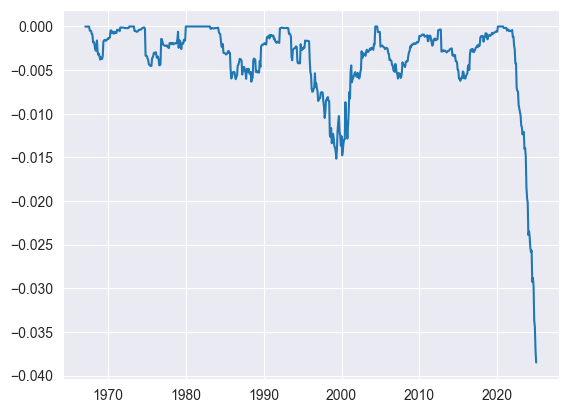

In [40]:
sum_spc_ebc_weights = SPC_EBC_weights.sum(axis=1)
plt.plot(sum_spc_ebc_weights)

In [41]:

returns_aligned = returns_aligned.fillna(0)
long_returns = (returns_aligned * long_aligned).sum(axis=1)
short_returns = (returns_aligned * short_aligned).sum(axis=1)
SPC_EBC_returns = (returns_aligned * SPC_EBC_weights).sum(axis=1)


In [42]:
import pandas as pd

EBC_returns = pd.read_csv(
    "equal_beta_portfolio_return.csv",
    index_col=0,
    parse_dates=True
)

# shift index to the last calendar day of each month
EBC_returns.index = EBC_returns.index + pd.offsets.MonthEnd(0)

EBC_returns.head()


,0
date,
1967-01-31,0.105809
1967-02-28,0.007303
1967-03-31,0.043577
1967-04-30,0.032736
1967-05-31,-0.027935


In [43]:
portfolio_returns = (pd.concat(
    [EBC_returns, long_returns, short_returns], axis=1
).set_axis(["EBC_returns", "long_returns", "short_returns"], axis=1).dropna(how= "any"))


In [44]:
portfolio_returns["short_returns"].to_csv("Cap-EBC_Short_Returns.csv")
portfolio_returns["long_returns"].to_csv("Cap-EBC_Long_Returns.csv")

In [45]:
portfolio_returns.tail(100)

,EBC_returns,long_returns,short_returns
date,,,
2016-09-30,-0.000691,0.005073,-0.001145
2016-10-31,-0.024482,-0.010573,-0.030069
2016-11-30,0.042749,0.032720,0.032075
2016-12-31,0.014249,0.026793,0.013009
2017-01-31,0.019341,0.022856,0.015984
...,...,...,...
2024-08-31,0.030202,0.022697,0.028458
2024-09-30,0.016253,0.030889,0.015577
2024-10-31,-0.016896,-0.000747,-0.021515


In [46]:
sp_returns = pd.read_csv("sp500_capweighted_returns.csv", index_col=0, parse_dates=True)

In [47]:
common_idx = return_data.index.intersection(long_portfolio.index).intersection(short_portfolio.index).intersection(sp_returns.index)
common_cols = return_data.columns.intersection(long_portfolio.columns).intersection(short_portfolio.columns)

In [48]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm

def run_fmb_multi(sp500, factor_returns, ROLLING_WINDOW=36, MIN_OBS=10):
    """2 pass multi factor Fama-MacBeth"""

    asset_cols = sp500.columns
    combined = sp500.join(factor_returns, how="inner")

    # Prepare betas containers as float from the start
    betas_dict = {
        f: pd.DataFrame(index=pd.Index([], name="date"), columns=asset_cols, dtype=float)
        for f in factor_returns.columns
    }
    beta_dates = []

    # ---------- First pass: rolling time-series ----------
    for end_date in tqdm(combined.index[ROLLING_WINDOW-1:-1], desc="Time-series betas"):
        pos = combined.index.get_loc(end_date)
        next_date = combined.index[pos + 1]

        start_idx = pos - (ROLLING_WINDOW - 1)
        window_dates = combined.index[start_idx: start_idx + ROLLING_WINDOW]

        # Build window, drop any rows where either y or X has NaN
        x_win = factor_returns.loc[window_dates]
        for asset in asset_cols:
            y_win = sp500.loc[window_dates, asset]
            data = pd.concat([y_win, x_win], axis=1).dropna()
            if len(data) < MIN_OBS:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            Y = pd.to_numeric(data[asset], errors="coerce").astype(float)
            X = sm.add_constant(
                data[factor_returns.columns].apply(pd.to_numeric, errors="coerce").astype(float),
                has_constant="add"
            )

            # Guard against singular matrix if too few distinct X rows
            if X.shape[0] <= X.shape[1] or np.linalg.matrix_rank(X) < X.shape[1]:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            res = sm.OLS(Y, X).fit()

            for f in factor_returns.columns:
                betas_dict[f].loc[next_date, asset] = res.params.get(f, np.nan)

        beta_dates.append(next_date)

    # ---------- Second pass: cross-sectional ----------
    lambda_records = []
    alphas = []
    valid_index = []

    for date in tqdm(beta_dates, desc="Cross-sectional λ and α"):
        if date not in sp500.index:
            continue

        returns_t = pd.to_numeric(sp500.loc[date], errors="coerce").astype(float).dropna()

        # Collect that date’s betas across factors, force float
        betas_t = pd.DataFrame({
            f: pd.to_numeric(betas_dict[f].loc[date], errors="coerce").astype(float)
            for f in factor_returns.columns
        })

        # Keep assets that have both return and all betas
        betas_t = betas_t.dropna(axis=0, how="any")
        common_assets = returns_t.index.intersection(betas_t.index)

        # Need at least factors+1 obs to estimate with constant
        if len(common_assets) < max(MIN_OBS, len(factor_returns.columns) + 2):
            continue

        y_cs = returns_t.loc[common_assets].astype(float)
        X_cs = sm.add_constant(betas_t.loc[common_assets].astype(float), has_constant="add")

        # Extra guard against singular design
        if X_cs.shape[0] <= X_cs.shape[1] or np.linalg.matrix_rank(X_cs) < X_cs.shape[1]:
            continue

        res_cs = sm.OLS(y_cs, X_cs).fit()
        alphas.append(res_cs.params["const"])
        lambda_records.append(res_cs.params.drop("const"))
        valid_index.append(date)

    # Assemble outputs
    lambdas_df = pd.DataFrame(lambda_records, index=pd.Index(valid_index, name="date"))
    # Ensure columns ordering matches factor order
    lambdas_df = lambdas_df.reindex(columns=factor_returns.columns)

    alpha_series = pd.Series(alphas, index=lambdas_df.index, name="alpha")

    # Simple FM t-stats (no HAC)
    T = len(lambdas_df)
    lambda_tstats = lambdas_df.mean() / (lambdas_df.std(ddof=1) / np.sqrt(T))
    alpha_tstat  = alpha_series.mean() / (alpha_series.std(ddof=1) / np.sqrt(T))

    return betas_dict, lambdas_df, alpha_series, lambda_tstats, alpha_tstat


In [49]:
long_returns.name = "Long_Factor"
short_returns.name = "Short_Factor"


betas, lambdas, alphas, lambda_tstats, alpha_tstats,  = run_fmb_multi(returns_aligned, portfolio_returns)


Cross-sectional λ and α: 100%|██████████| 660/660 [00:01<00:00, 615.30it/s]


In [26]:
print(lambda_tstats)

EBC_returns      4.384388
long_returns     3.863155
short_returns    4.413362
dtype: float64


In [27]:
print(alpha_tstats)

4.880946534029505


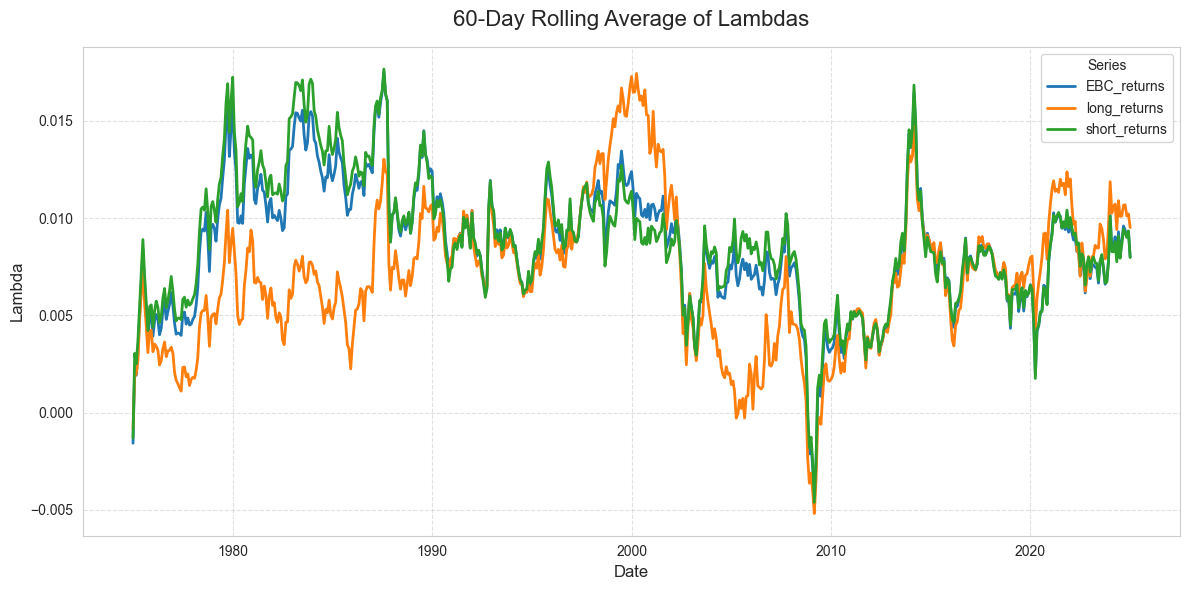

In [57]:

rolling_lambdas = lambdas.rolling(60).mean().dropna()


import matplotlib.pyplot as plt

# compute rolling mean of lambdas
rolling_lambdas = lambdas.rolling(60).mean().dropna()

# set figure size
plt.figure(figsize=(12, 6))

# plot each column with nice labels
for col in rolling_lambdas.columns:
    plt.plot(rolling_lambdas.index, rolling_lambdas[col], label=col, linewidth=2)

# add title and labels
plt.title("60-Day Rolling Average of Lambdas", fontsize=16, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Lambda", fontsize=12)

# grid, legend, and style tweaks
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Series", fontsize=10)
plt.tight_layout()

plt.show()


In [29]:
betas

{'EBC_returns':                  ACF       ABK       AMT  JAVA        AN      ORCL      MSFT  \
 date                                                                           
 1971-09-30  3.396567  3.086641 -4.874550   0.0 -1.662785  0.000000  0.000000   
 1971-11-30  3.707062  4.165372 -4.350216   0.0 -2.445857  0.000000  0.000000   
 1971-12-31  3.528023  4.042866 -4.301240   0.0 -2.439971  0.000000  0.000000   
 1972-01-31  2.886326  3.402088 -1.991656   0.0 -1.742947  0.000000  0.000000   
 1972-02-29  3.199219  3.706999 -2.925576   0.0 -1.857627  0.000000  0.000000   
 ...              ...       ...       ...   ...       ...       ...       ...   
 2024-05-31  0.000000  0.000000  0.000000   0.0  0.000000  3.030377 -0.203780   
 2024-07-31  0.000000  0.000000  0.000000   0.0  0.000000  2.035548 -0.399422   
 2024-09-30  0.000000  0.000000  0.000000   0.0  0.000000  2.192529 -0.383157   
 2024-10-31  0.000000  0.000000  0.000000   0.0  0.000000  1.565802  0.253363   
 2024-12-31  

In [30]:
alphas

date
1971-09-30    0.000054
1971-11-30    0.000567
1971-12-31    0.003808
1972-01-31    0.001328
1972-02-29    0.001755
                ...   
2024-05-31    0.002167
2024-07-31    0.001637
2024-09-30   -0.000164
2024-10-31   -0.001083
2024-12-31   -0.001503
Name: alpha, Length: 450, dtype: float64

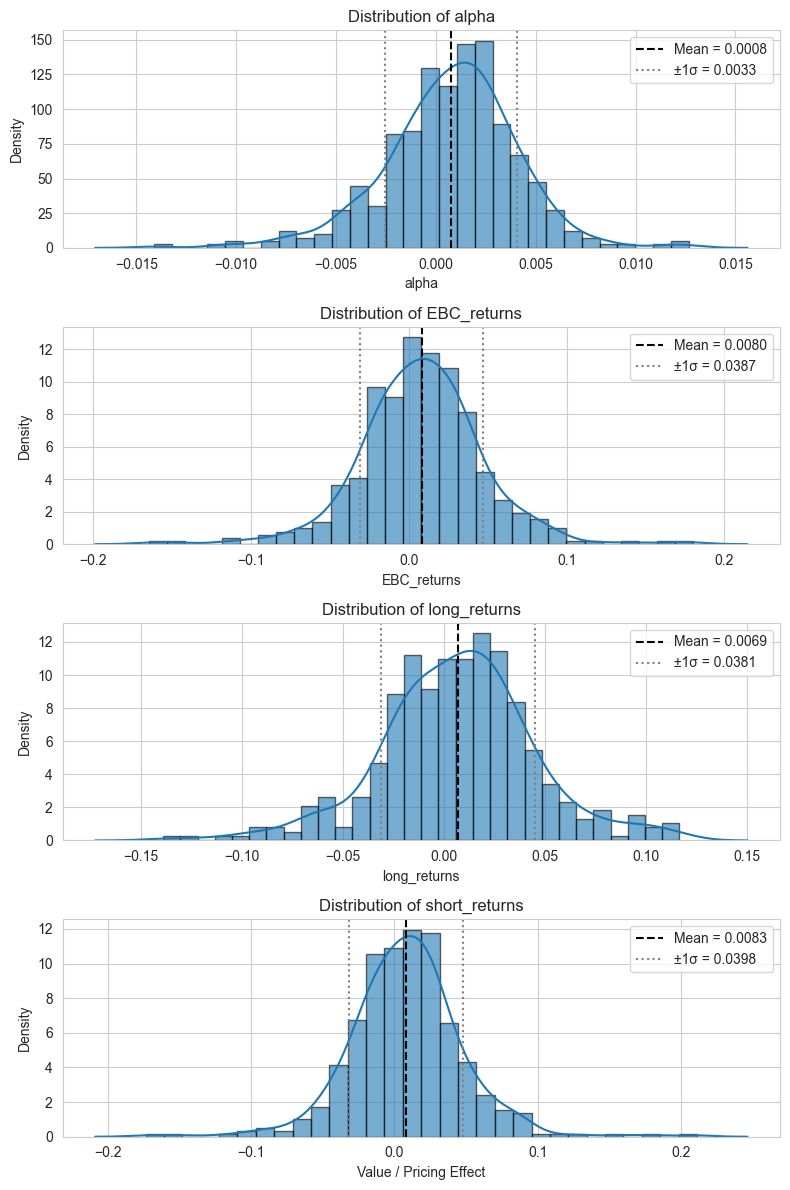

In [31]:
import matplotlib.pyplot as plt

# combine alpha + lambdas into a dictionary
distributions = {'alpha': alphas}
distributions.update({col: lambdas[col] for col in lambdas.columns})

n = len(distributions)
fig, axes = plt.subplots(n, 1, figsize=(8, 3*n), sharex=False)

for i, (name, series) in enumerate(distributions.items()):
    ax = axes[i]
    data = series.dropna()

    # histogram + density line
    ax.hist(data, bins=30, density=True, alpha=0.6, color='tab:blue', edgecolor='black')
    sns.kdeplot(data, ax=ax, color='tab:blue')

    # mean + 1 std lines
    mean = data.mean()
    std = data.std()
    ax.axvline(mean, color='black', linestyle='--', label=f"Mean = {mean:.4f}")
    ax.axvline(mean + std, color='gray', linestyle=':', label=f"±1σ = {std:.4f}")
    ax.axvline(mean - std, color='gray', linestyle=':')

    ax.set_title(f"Distribution of {name}")
    ax.set_ylabel("Density")
    ax.legend()

plt.xlabel("Value / Pricing Effect")
plt.tight_layout()
plt.show()
